In [22]:
import mysql.connector
import numpy as np
import pandas as pd
import zarr
import os
import matplotlib.pyplot as plt

In [14]:
HEIGHT = 256
WIDTH = 384

In [15]:
base_dir = "/Volumes/Transcend/zarrDB"
zarr_path = os.path.join(base_dir, "Haya2TIR.zarr")

# MySQL 接続
conn = mysql.connector.connect(
    user="root",
    password="",
    unix_socket="/tmp/mysql_database_dev.sock",
    database="heat_db",
)
cur = conn.cursor(dictionary=True)


In [16]:
cur.execute("SELECT * FROM tirimageinfo")
df = pd.DataFrame(cur.fetchall())
cur.close()
conn.close()

In [17]:
print(df.columns)
base_dir = "/Users/kengokakazu/研究用/HEAT/tileDB_migrate/zarrDB"
zarr_path = os.path.join(base_dir, "tirimageinfo.zarr")

Index(['img_file', 'thumbnail', 'path', 'date_time', 'm', 'place',
       'target_name', 'phi', 'hood_t', 'target_t', 'len_t', 'plt_t', 'bol_t',
       'img_id', 'plt_t_set', 'bol_t_mon', 'pkg_t_mon', 'case_t_mon',
       'sh_t_mon', 'lens_t_mon'],
      dtype='object')


In [18]:
root = zarr.open(zarr_path, mode="r")
pixel = root["pixel"]
pixel_modified = root["pixel_modified"]
mask = root["mask"]
filename_df = pd.read_csv(os.path.join(base_dir, "file_index_mapping.csv"))
pixel_area = [(x, y) for x in range(32) for y in range(32)]

In [19]:
weight_avg = np.zeros((HEIGHT,WIDTH,6))
intercept_avg = np.zeros((HEIGHT,WIDTH))


In [21]:

for x,y in pixel_area:
    m = filename_df.merge(df, left_on="filename", right_on="img_file", how="left")
    m = m.sort_values("file_idx")
    target_t = m["target_t"].to_numpy()
    vy = np.asarray(pixel_modified[:, y, x])   
    vx_df = m[["target_t", "bol_t_mon", "pkg_t_mon", "case_t_mon", "sh_t_mon", "lens_t_mon"]].rename(columns={"bol_t_mon":"bol_t","pkg_t_mon":"pkg_t","case_t_mon":"case_t","sh_t_mon":"sh_t","lens_t_mon":"lens_t"})     
    vx = vx_df.to_numpy()
    K_OFFSET = 273.15
    header = vx_df.columns.tolist()
    for c in header:
        vx_df[c] = vx_df[c] + K_OFFSET
    features = vx_df.columns.tolist()
    rng = np.random.default_rng(42)
    vx_aug = np.hstack([vx, np.ones((vx.shape[0], 1))])  
    w,residuals,rank,s = np.linalg.lstsq(vx_aug,vy)
    coef = w[:-1]
    intercept = w[-1]
    weight_avg[y,x,:] = coef
    intercept_avg[y,x] = intercept
    print("pixel: ", x, y,"finished")


pixel:  0 0 finished
pixel:  0 1 finished
pixel:  0 2 finished
pixel:  0 3 finished
pixel:  0 4 finished
pixel:  0 5 finished
pixel:  0 6 finished
pixel:  0 7 finished
pixel:  0 8 finished
pixel:  0 9 finished
pixel:  0 10 finished
pixel:  0 11 finished
pixel:  0 12 finished
pixel:  0 13 finished
pixel:  0 14 finished
pixel:  0 15 finished
pixel:  0 16 finished
pixel:  0 17 finished
pixel:  0 18 finished
pixel:  0 19 finished
pixel:  0 20 finished
pixel:  0 21 finished
pixel:  0 22 finished
pixel:  0 23 finished
pixel:  0 24 finished
pixel:  0 25 finished
pixel:  0 26 finished
pixel:  0 27 finished
pixel:  0 28 finished
pixel:  0 29 finished
pixel:  0 30 finished
pixel:  0 31 finished
pixel:  1 0 finished
pixel:  1 1 finished
pixel:  1 2 finished
pixel:  1 3 finished
pixel:  1 4 finished
pixel:  1 5 finished
pixel:  1 6 finished
pixel:  1 7 finished
pixel:  1 8 finished
pixel:  1 9 finished
pixel:  1 10 finished
pixel:  1 11 finished
pixel:  1 12 finished
pixel:  1 13 finished
pixel:  

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (32, 32) and arg 2 with shape (256, 384).

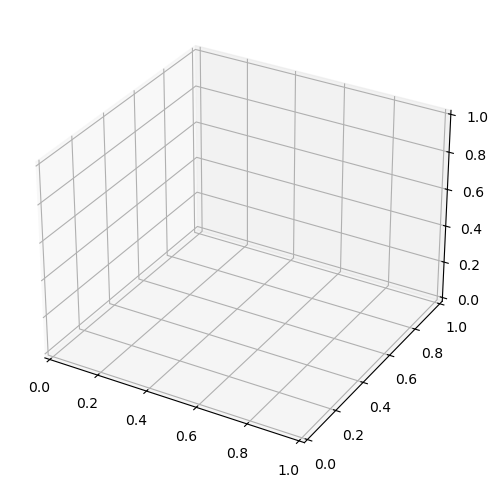

In [ ]:
H, W = HEIGHT, WIDTH

# 空間は局所ウィンドウのみ（x,y を広げない）
Hc, Wc = 32, 32
intercept_roi = intercept_avg[:Hc, :Wc]
weight_roi = weight_avg[:Hc, :Wc, :]
yy, xx = np.meshgrid(np.arange(Hc), np.arange(Wc), indexing="ij")

def _z_range_lo_hi(arr):
    lo = float(np.nanmin(arr))
    hi = float(np.nanmax(arr))
    if not np.isfinite(lo) or not np.isfinite(hi):
        return 0.0, 1.0
    if hi <= lo:
        hi = lo + 1e-12
    pad = 0.02 * (hi - lo)
    return lo - pad, hi + pad

# --- intercept: 描画は 32x32、Z 軸とカラーの範囲は全画素の min/max ---
z_lo, z_hi = _z_range_lo_hi(intercept_avg)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(
    xx, yy, intercept_roi,
    cmap="viridis", linewidth=0, antialiased=True,
    vmin=z_lo, vmax=z_hi,
)
ax.set_zlim(z_lo, z_hi)
ax.set_title("intercept_avg surface (32x32)  Z/colormap range = full image min/max")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("intercept")
fig.colorbar(surf, ax=ax, shrink=0.6, label="intercept")
plt.show()

# --- weight: 各特徴量ごと。空間は 32x32、Z/カラーはその特徴量チャンネル全画素の min/max ---
feature_names = ["target_t", "bol_t", "pkg_t", "case_t", "sh_t", "lens_t"]

for k in range(weight_roi.shape[2]):
    z = weight_roi[:, :, k]
    w_lo, w_hi = _z_range_lo_hi(weight_avg[:, :, k])
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(
        xx, yy, z,
        cmap="coolwarm", linewidth=0, antialiased=True,
        vmin=w_lo, vmax=w_hi,
    )
    ax.set_zlim(w_lo, w_hi)
    name = feature_names[k] if k < len(feature_names) else k
    ax.set_title(f"weight_avg: {name} (32x32)  Z/colormap range = full image min/max")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("weight")
    fig.colorbar(surf, ax=ax, shrink=0.6, label="weight")
    plt.show()
